In [1]:
import os
import sys
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv.imread('dogs.jpg')

img.shape

(3888, 5184, 3)

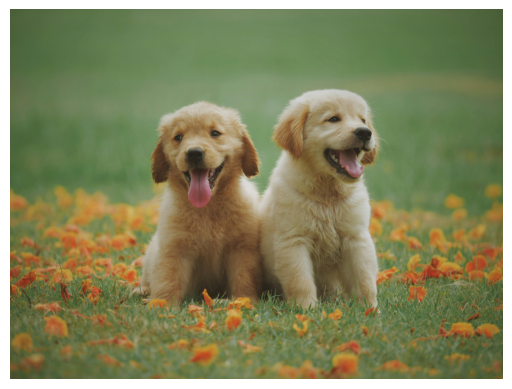

In [4]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

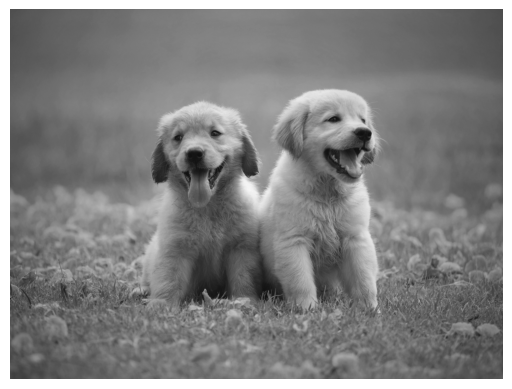

In [5]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

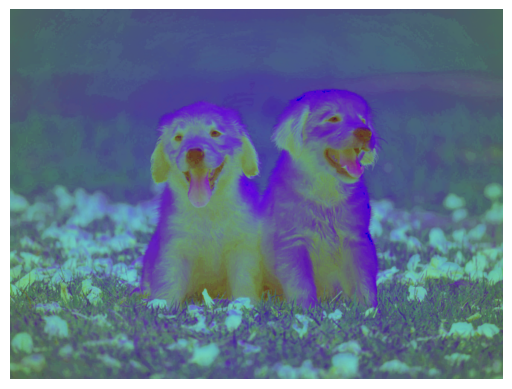

In [6]:
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_BGR2HSV)
plt.imshow(img_hsv)
plt.axis('off')
plt.show()

In [7]:
ksize = 81
blurred = cv.blur(img_rgb, (ksize, ksize))
gauss = cv.GaussianBlur(img_rgb, (ksize, ksize), 0)
median = cv.medianBlur(img_rgb, ksize)

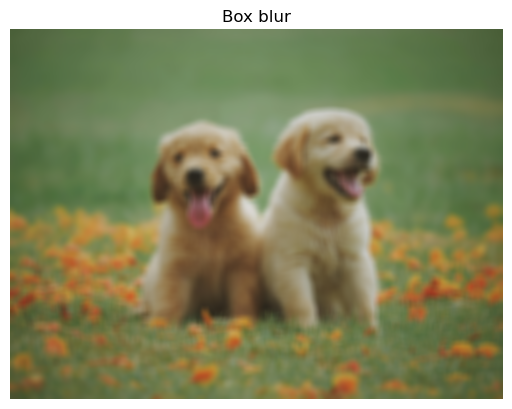

In [8]:
plt.title("Box blur")
plt.imshow(blurred)
plt.axis("off")
plt.show()

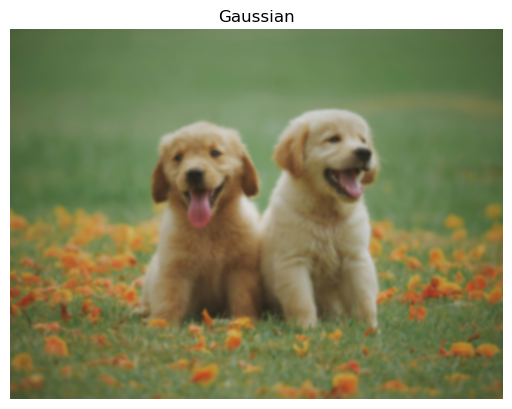

In [9]:
plt.title("Gaussian")
plt.imshow(gauss)
plt.axis("off")
plt.show()

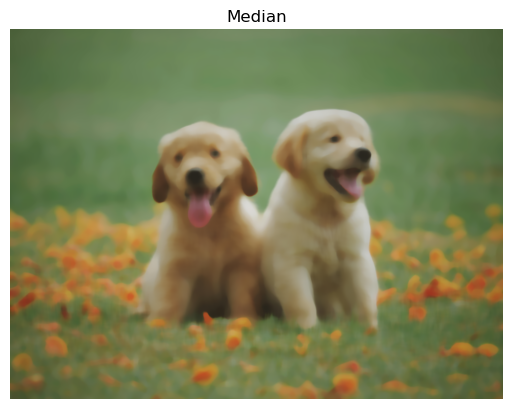

In [10]:
plt.title("Median")
plt.imshow(median)
plt.axis("off")
plt.show()

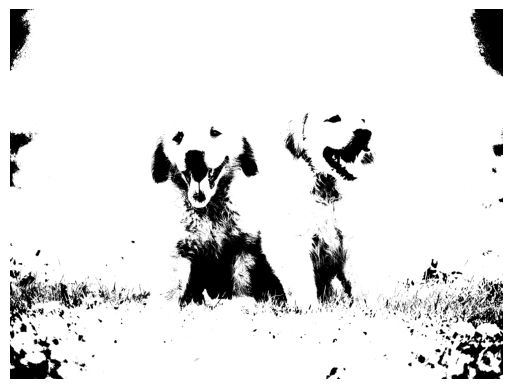

In [11]:
ret, thresh = cv.threshold(gray, 90, 255, cv.THRESH_BINARY)
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

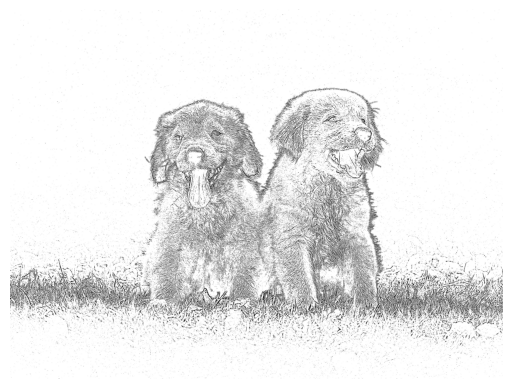

In [12]:
thresh = cv.adaptiveThreshold(
    src=gray,
    maxValue=255,
    adaptiveMethod=cv.ADAPTIVE_THRESH_MEAN_C,
    thresholdType=cv.THRESH_BINARY,
    blockSize=11,
    C=3
)

plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

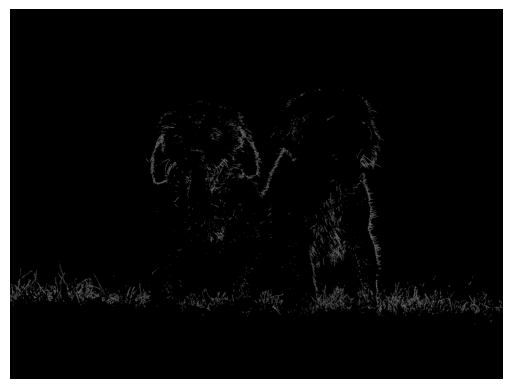

In [13]:
edge = cv.Canny(img, 100, 200)
plt.imshow(edge, cmap='gray')
plt.axis('off')
plt.show()

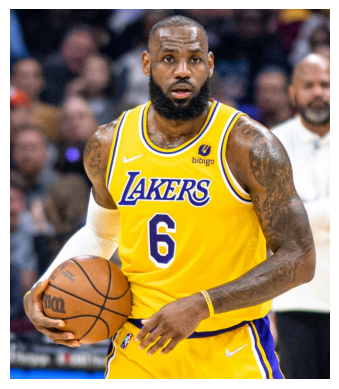

In [14]:
lebron = cv.imread('lebron.jpg')

lebron = cv.cvtColor(lebron, cv.COLOR_BGR2RGB)
plt.imshow(lebron)
plt.axis('off')
plt.show()

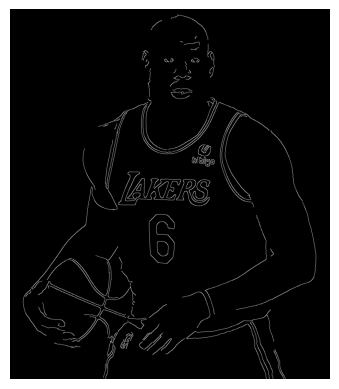

In [15]:
lsize = 5
blur = cv.blur(lebron, (lsize, lsize))
graybron = cv.cvtColor(blur, cv.COLOR_RGB2GRAY)
edge = cv.Canny(graybron, 100, 200)
plt.imshow(edge, cmap='gray')
plt.axis('off')
plt.show()

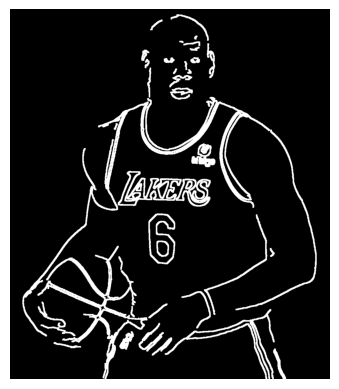

In [16]:
dilated = cv.dilate(edge, np.ones((5, 5), np.uint8), iterations=1)
plt.imshow(dilated, cmap='gray')
plt.axis('off')
plt.show()

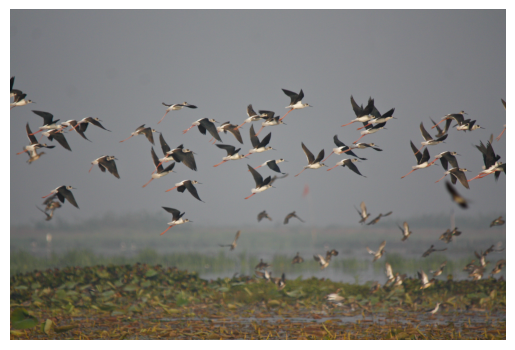

In [17]:
birds = cv.imread('birds.jpg')
birds = cv.cvtColor(birds, cv.COLOR_BGR2RGB)
plt.imshow(birds)
plt.axis('off')
plt.show()

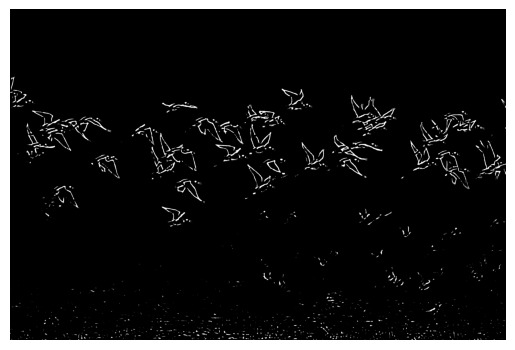

In [18]:
birds_blur = cv.blur(birds, (15,15))
birds_gray = cv.cvtColor(birds_blur, cv.COLOR_RGB2GRAY)
birds_tresh = cv.adaptiveThreshold(
    src=birds_gray,
    maxValue=255,
    adaptiveMethod=cv.ADAPTIVE_THRESH_MEAN_C,
    thresholdType=cv.THRESH_BINARY_INV,
    blockSize=11,
    C=3
)
plt.imshow(birds_tresh, cmap='gray')
plt.axis('off')
plt.show()

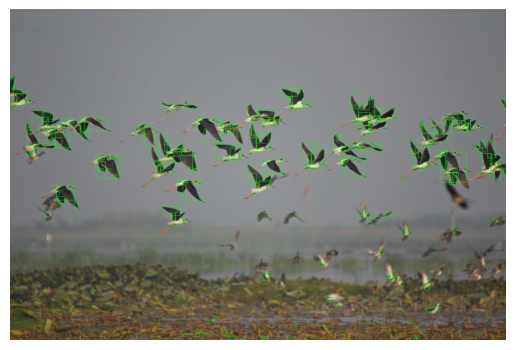

In [19]:
countours, hierarchy = cv.findContours(
    birds_tresh,
    mode=cv.RETR_EXTERNAL,
    method=cv.CHAIN_APPROX_SIMPLE
)
for cnt in countours:
    if cv.contourArea(cnt) > 100:
        x, y, w, h = cv.boundingRect(cnt)
        cv.rectangle(birds, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(birds, cmap='gray')
plt.axis('off')
plt.show()